In [58]:
#!/usr/bin/env python
# coding: utf-8


import sys
# sys.path.insert(0, "/Users/anaegel/Software/ug4-git")
sys.path.append("..")



import ug4py.pyugcore as ugcore
# import ug4py.pyconvectiondiffusion as cd
import ug4py.pysmallstrainmechanics as mech
import ug4py.pyutil as pyutil


import math  # For sqrt, sin, exp, ...

import modsimtools as util

In [85]:
class rubber :
    E = 0.1 * 1e+9
    nu = 0.499


class steel :
    E = 200 * 1e+9
    nu = 0.3


class concrete :
    E = 20 * 1e+9

    nu = 0.15



In [88]:
# ## Problem definitions
class Mycubeproblem:
    # Geometrie
    gridName= "mycube_5cm.ugx" 
    requiredSubsets = {"Inner",  "bottomface", "topface"}
    
    numRefs= 2
    
    # Constructor
    def __init__(self, E =200e9, nu=0.4):
        #Material parameters
        # E=200 GPa
        # nu=-30
        
        self.EYoung = E
        self.nu = nu

        matLaw = mech.HookeLaw3d()
        matLaw.set_hooke_elasticity_tensor_E_nu(self.EYoung, self.nu)
        
        elemDisc = mech.SmallStrainMechanics3d("ux, uy, uz", "Inner")
        elemDisc.set_quad_order(2)  # TODO: must be increased for higher order elements.

        elemDisc.set_material_law(matLaw)
        # elemDisc:set_volume_forces(volumeForceField)
        elemDisc.set_mass_scale(0.0)

        self.elemDisc = elemDisc

        self.dirichletBND = ugcore.DirichletBoundary3dCPU1()
 	# Compress (negative value) the top of the cube
       #  self.dirichletBND.add(-0.10, "uz", "Top") 
        self.dirichletBND.add(-0.02*1e-4, "uz", "topface") # 0.02 mm
        
    # Boundary conditions
    # Fix any deformation at the bottom of the cube.
        self.dirichletBND.add(0.0, "ux", "bottomface") 
        self.dirichletBND.add(0.0, "uy", "bottomface") 
        self.dirichletBND.add(0.0, "uz", "bottomface") 
        
       
        
    
    # API function
    def CreateDomainDisc(self,approxSpace):   
        domainDisc = ugcore.DomainDiscretization3dCPU1(approxSpace)  
        domainDisc.add(self.elemDisc)
        domainDisc.add(self.dirichletBND)
        return domainDisc
    
    # Callback fuer rechte Seite
    def SomeCallback(self, x, y, t, si):
        return 47.11


In [89]:
mymaterial = steel

print(mymaterial.E)
print(mymaterial.nu)
problem = Mycubeproblem(E=mymaterial.E, nu=mymaterial.nu) # E in GPa

result = ", ".join(problem.requiredSubsets)
print(result)
dom = pyutil.CreateDomain3d(problem.gridName, problem.numRefs, )

approxSpace = ugcore.ApproximationSpace3d(dom)
approxSpace.add_fct("ux", "Lagrange", 1)
approxSpace.add_fct("uy", "Lagrange", 1)
approxSpace.add_fct("uz", "Lagrange", 1)
approxSpace.init_levels()
approxSpace.init_top_surface()

domainDisc = problem.CreateDomainDisc(approxSpace)


# ### Assemble and solve linear system (as usual)
Ah = ugcore.AssembledLinearOperatorCPU1(domainDisc)
uh = ugcore.GridFunction3dCPU1(approxSpace)
bh = ugcore.GridFunction3dCPU1(approxSpace)

import traceback
try:
    domainDisc.assemble_linear(Ah, bh)
    domainDisc.adjust_solution(uh)
except Exception as inst:
    traceback.print_exc()
    print(str(inst))



# Create multigrid solver.
sys.path.append("..")
import util.solver_util as util_solver

gmg = util_solver.CreateMultigridPrecond3D(approxSpace, domainDisc, "V",2,2) # TODO: GMG requires a block solver.
gmg.set_discretization(domainDisc)

solver = ugcore.LinearSolverCPU1()
solver.set_preconditioner(gmg)
solver.set_convergence_check(util_solver.convCheck)

# Solve the linear system
solver = ugcore.LUCPU1()

# In[124]:


try:
    solver.init(Ah, uh)
    solver.apply(uh, bh)
except Exception as inst:
    traceback.print_exc()
    print(inst)
    


# In[125]:


ugcore.WriteGridFunctionToVTK(uh, "mycube.vtu")


200000000000.0
0.3
bottomface, Inner, topface
Loading Domain mycube_5cm.ugx ... done.
Performing integrity check on domain ... done.
Refining(2): 0 1 done.


In [90]:
try:
    import pyvista
    #pyvista.start_xvfb()
    #pyvista.set_jupyter_backend('trame')
    pyvista.set_jupyter_backend('static')

except Exception:
    pyvista=None



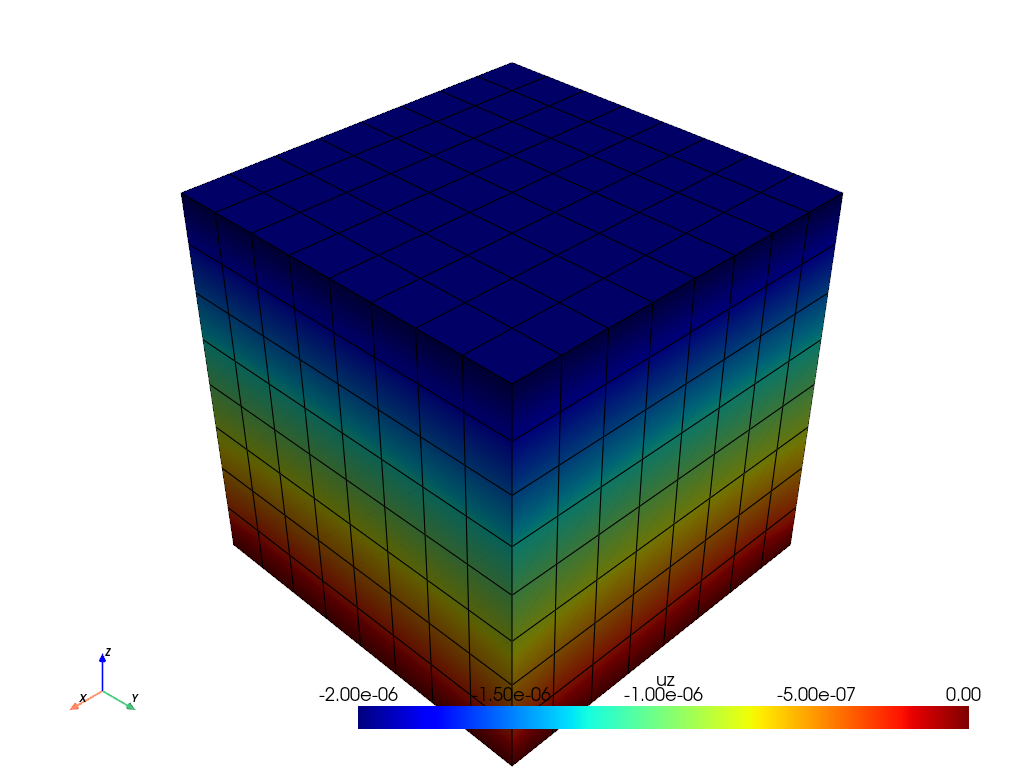

In [91]:
if pyvista is not None:
    result = pyvista.read("mycube.vtu")
    result.plot(scalars="uz", show_edges=True, cmap='jet')  
 
 